# Exploratory Data Analysis — Ames Housing

This notebook inspects the [Ames Housing](https://www.kaggle.com/c/house-prices-advanced-regression-techniques) training set and identifies the strongest linear correlates of `SalePrice`.


In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

ROOT = Path.cwd().resolve()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT / "src"))

from house_price_predictor import load_housing_data, correlation_with_target, select_correlated_features

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (12, 6)


In [2]:
train, test = load_housing_data()
print(train.shape, test.shape)
train.head()


(1460, 81) (1459, 80)


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [3]:
corr = correlation_with_target(train)
top = corr.head(12)
display(top)
features = select_correlated_features(train, threshold=0.5)
print("Features with |r| >= 0.5:", features)


OverallQual     0.790982
GrLivArea       0.708624
GarageCars      0.640409
GarageArea      0.623431
TotalBsmtSF     0.613581
1stFlrSF        0.605852
FullBath        0.560664
TotRmsAbvGrd    0.533723
YearBuilt       0.522897
YearRemodAdd    0.507101
GarageYrBlt     0.486362
MasVnrArea      0.477493
Name: SalePrice, dtype: float64

Features with |r| >= 0.5: ['OverallQual', 'GrLivArea', 'GarageCars', 'GarageArea', 'TotalBsmtSF', '1stFlrSF', 'FullBath', 'TotRmsAbvGrd', 'YearBuilt', 'YearRemodAdd']


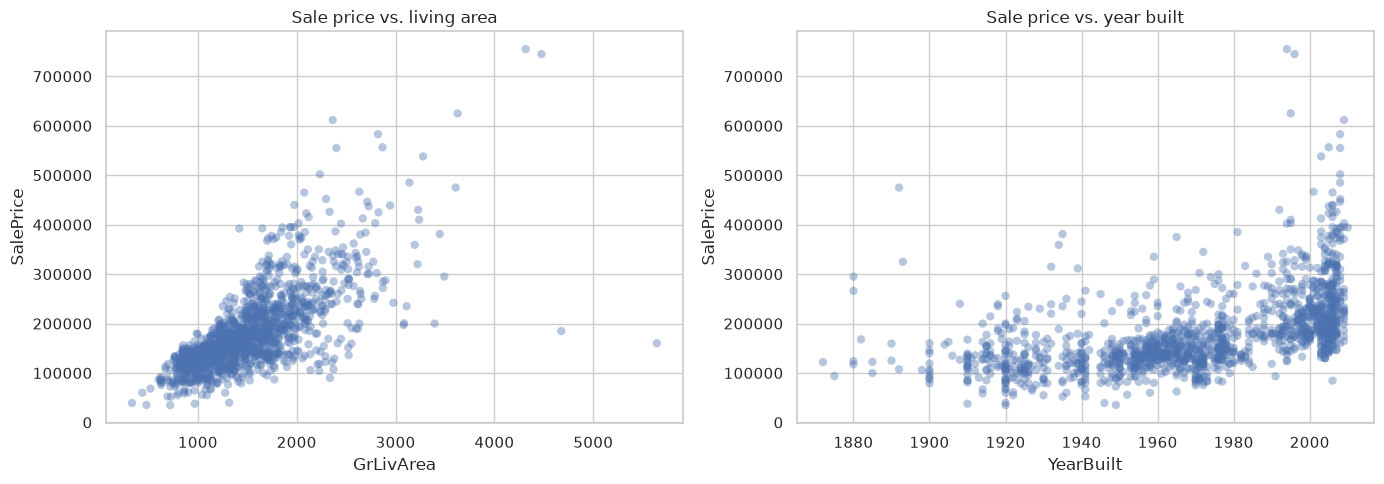

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].scatter(train["GrLivArea"], train["SalePrice"], alpha=0.4, edgecolor="none")
axes[0].set_xlabel("GrLivArea"); axes[0].set_ylabel("SalePrice")
axes[0].set_title("Sale price vs. living area")
axes[1].scatter(train["YearBuilt"], train["SalePrice"], alpha=0.4, edgecolor="none")
axes[1].set_xlabel("YearBuilt"); axes[1].set_ylabel("SalePrice")
axes[1].set_title("Sale price vs. year built")
plt.tight_layout()
plt.savefig(ROOT / "artifacts" / "eda_scatter.png", dpi=120)
plt.show()


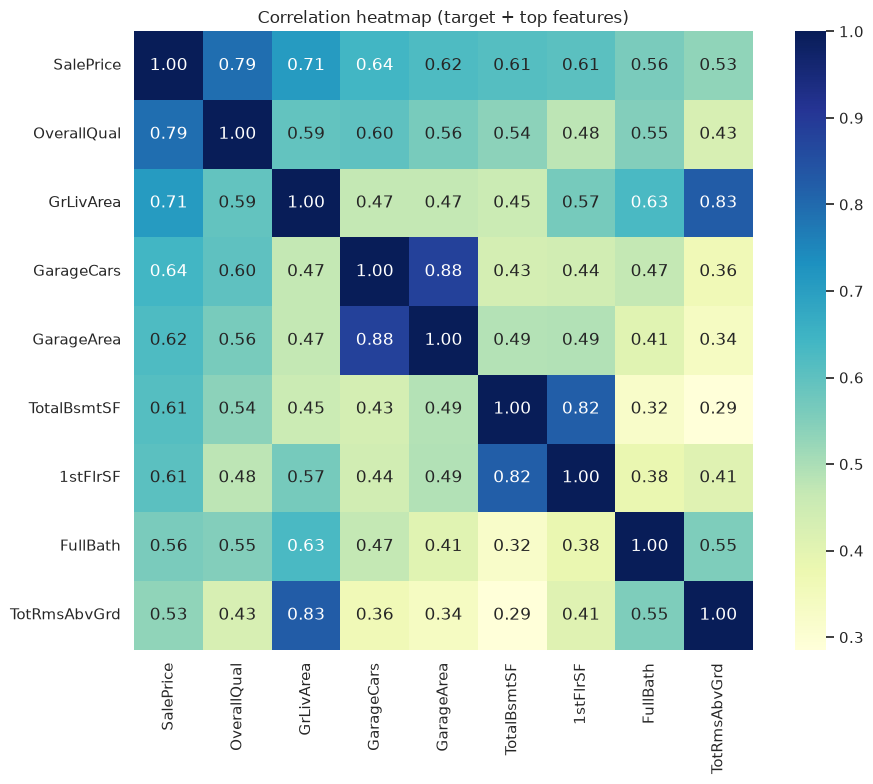

In [5]:
num = train.select_dtypes(include=[np.number])
cols = ["SalePrice"] + features[:8]
cm = num[cols].corr()
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt=".2f", cmap="YlGnBu", square=True)
plt.title("Correlation heatmap (target + top features)")
plt.tight_layout()
plt.savefig(ROOT / "artifacts" / "eda_corr_heatmap.png", dpi=120)
plt.show()


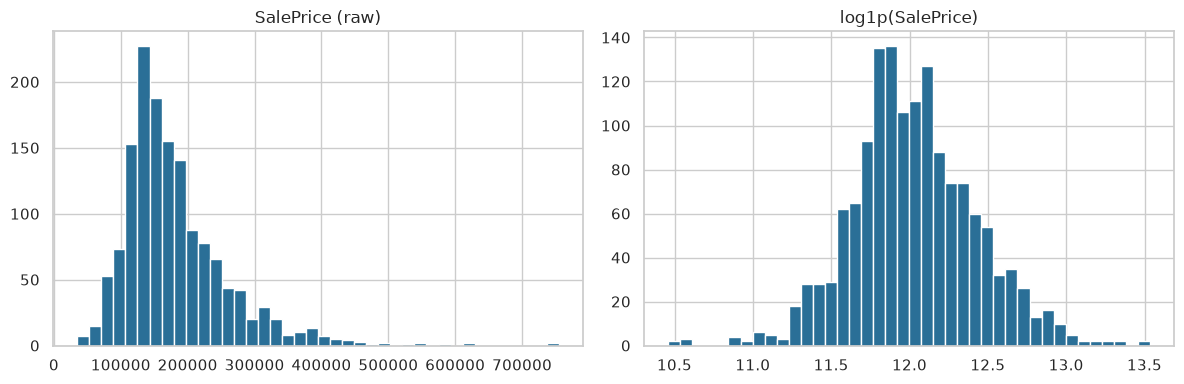

In [6]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].hist(train["SalePrice"], bins=40, color="#2a6f97")
ax[0].set_title("SalePrice (raw)")
ax[1].hist(np.log1p(train["SalePrice"]), bins=40, color="#2a6f97")
ax[1].set_title("log1p(SalePrice)")
plt.tight_layout()
plt.savefig(ROOT / "artifacts" / "eda_target_distribution.png", dpi=120)
plt.show()
